# Рубежный контроль №1

## Тема: Технологии разведочного анализа и обработки данных.

### Исполнитель: Мефодьев Илья Николаевич, группа ИУ5Ц-82Б

Вариант: 28; Номер задачи: 4; Номер набора данных: 4;

Для студентов групп ИУ5-62Б, ИУ5Ц-82Б - для произвольной колонки данных построить гистограмму


**Задача №4.**

Для заданного набора данных постройте основные графики, входящие в этап разведочного анализа данных. В случае наличия пропусков в данных удалите строки или колонки, содержащие пропуски. Какие графики Вы построили и почему? Какие выводы о наборе данных Вы можете сделать на основании построенных графиков?

## Ход выполнения

Работаю с датасетом **Heart Disease Dataset** - https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset

Этот набор данных датируется 1988 годом и состоит из четырех баз данных в клиниках: Кливленд, Венгрия, Швейцария и Лонг-Бич V. Он содержит 76 атрибутов, включая прогнозируемый атрибут, но во всех опубликованных экспериментах упоминается использование подмножества из 14 из них. 

Поле «цель» указывает на наличие сердечного заболевания у пациента. 

Оно имеет целочисленное значение: 0 = отсутствие заболевания и 1 = наличие заболевания.

В датасете следующие поля:

1. **age** - Возраст пациента

2. **sex** - Пол пациента (1 = male; 0 = female)

3. **CP = chest pain type (4 values)** - Тип боли в груди

4. **trestbps = resting blood pressure** - Артериальное давление в состоянии покоя (в мм рт. ст. при поступлении в больницу)

5. **chol = serum cholestoral in mg/dl** - уровень холестерина в сыворотке крови (мг/дл)

6. **fbs = fasting blood sugar > 120 mg/dl** - Уровень сахара в крови натощак > 120 мг/дл (1 = верно; 0 = неверно)

7. **restecg = resting electrocardiographic results (values 0,1,2)** - результаты электрокардиографии в состоянии покоя

8. **thalach = maximum heart rate achieved** - максимальная частота сердечных сокращений

9. **exang = exercise induced angina** - стенокардия, вызванная физической нагрузкой

10. **oldpeak = ST depression induced by exercise relative to rest** - Снижение сегмента ST, вызванное физической нагрузкой, по сравнению с состоянием покоя

11. **slope = the slope of the peak exercise ST segment** - наклон пикового сегмента ST во время физической нагрузки

12. **ca = number of major vessels (0-3) colored by flourosopy** - количество крупных сосудов (0-3), окрашенных с помощью флюороскопии

13. **thal: 0 = normal; 1 = fixed defect; 2 = reversable defect** - таламус: 0 = норма; 1 = фиксированный дефект; 2 = обратимый дефект

14. **target** - Поле «цель» указывает на наличие сердечного заболевания у пациента. 1 или 0


Первым делом импортируем необходимые библиотеки и выведем первые 10 элементов датасета

In [1]:
# добавим необходимые модули
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
HEART_ORIGIN = pd.read_csv("./heart.csv")

HEART_ORIGIN.head(10)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
5,58,0,0,100,248,0,0,122,0,1.0,1,0,2,1
6,58,1,0,114,318,0,2,140,0,4.4,0,3,1,0
7,55,1,0,160,289,0,0,145,1,0.8,1,1,3,0
8,46,1,0,120,249,0,0,144,0,0.8,2,0,3,0
9,54,1,0,122,286,0,0,116,1,3.2,1,2,2,0


Для начала посмотрим на ситуацию с пропусками

In [3]:
print('Всего строк: {}'.format(HEART_ORIGIN.shape[0]))

print(f"\nВсего пропусков: {HEART_ORIGIN.isnull().sum().sum()}")

for i in list(HEART_ORIGIN.columns):
    print(i + "\t" + str(HEART_ORIGIN[i].isnull().sum()) + "\t" + str(round(HEART_ORIGIN[i].isnull().mean()*100, 2)) + "%")

Всего строк: 1025

Всего пропусков: 0
age	0	0.0%
sex	0	0.0%
cp	0	0.0%
trestbps	0	0.0%
chol	0	0.0%
fbs	0	0.0%
restecg	0	0.0%
thalach	0	0.0%
exang	0	0.0%
oldpeak	0	0.0%
slope	0	0.0%
ca	0	0.0%
thal	0	0.0%
target	0	0.0%


Отличные новости! Пропусков нету, следовательно, не нужно с ними работать

Дальше сразу построим гистограмму возрастов пациентов

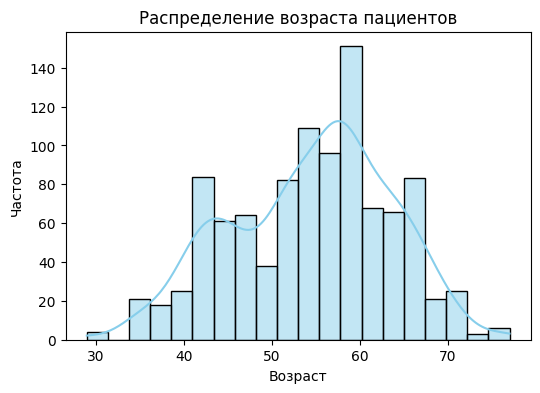

In [4]:
plt.figure(figsize=(6, 4))
sns.histplot(data=HEART_ORIGIN, x='age', bins=20, kde=True, color='skyblue')
plt.title('Распределение возраста пациентов')
plt.xlabel('Возраст')
plt.ylabel('Частота')
plt.show()

На гистограмме видно, что большинство пациентов прибывает в возрасте 60 лет. Также есть скачок в группе сорокалетних.

Далее построим корреляционную тепловую карту

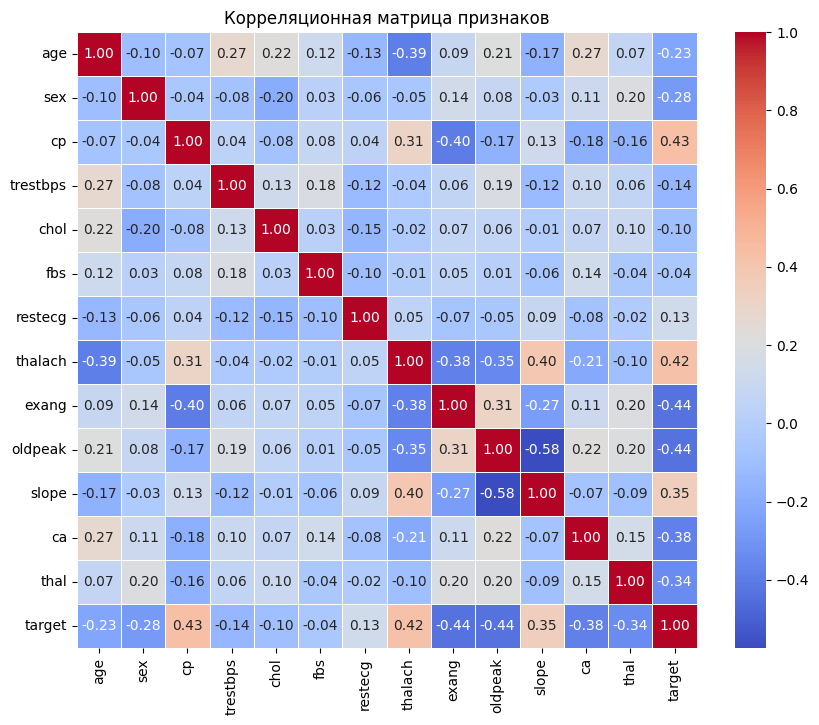

In [5]:
plt.figure(figsize=(10, 8))
sns.heatmap(HEART_ORIGIN.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Корреляционная матрица признаков')
plt.show()

Сильных корреляций не найдено, хотя обратных корреляций немало. В глаза бросается обратная корреляция между наклоном и падением ST (не могу сказать, что именно означает этот медицинский термин)

Далее посмотрим на распределение целевой переменной - есть ли у пациента сердечное заболевание?

/tmp/ipykernel_13349/2405496964.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=HEART_ORIGIN, x='target', palette='pastel')


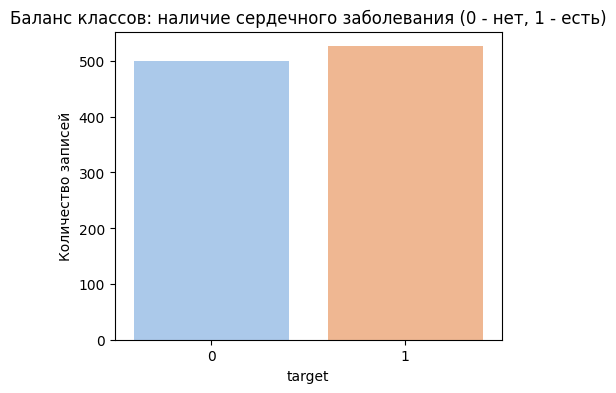

In [6]:
plt.figure(figsize=(5, 4))
sns.countplot(data=HEART_ORIGIN, x='target', palette='pastel')
plt.title('Баланс классов: наличие сердечного заболевания (0 - нет, 1 - есть)')
plt.xlabel('target')
plt.ylabel('Количество записей')
plt.show()

Видно, что пропорция почти равная, что неудивительно, учитывая места сбора статистики. Например, в армейской казарме статистика была бы куда сильнее выражена в пользу здоровых людей

Далее посмотрим, например, макисмальную ЧСС для людей с сердечными заболеваниями и без него

/tmp/ipykernel_13349/3917093770.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=HEART_ORIGIN, x='target', y='thalach', palette='Set2')


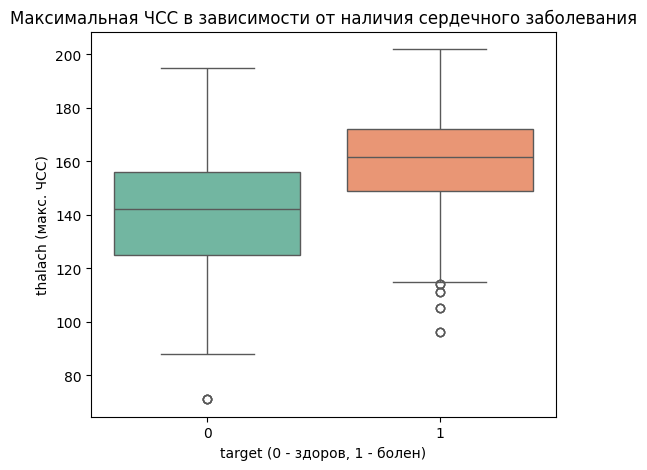

In [7]:
plt.figure(figsize=(6, 5))
sns.boxplot(data=HEART_ORIGIN, x='target', y='thalach', palette='Set2')
plt.title('Максимальная ЧСС в зависимости от наличия сердечного заболевания')
plt.xlabel('target (0 - здоров, 1 - болен)')
plt.ylabel('thalach (макс. ЧСС)')
plt.show()

Результат ожидаемый - у "сердечников" ЧСС оказалась выше, чем у людей без сердечных заболеваний

## Построенные графики и обоснование выбора
1. **Гистограмма `age`** — для анализа распределения возрастного состава выборки.
2. **Тепловая карта корреляций** — поиск корреляций между признаками.
3. **Столбчатая диаграмма `target`** — проверка баланса классов.
4. **Boxplot `thalach` по `target`** — визуальное сравнение показателя у пациентов с болезнью и без.

## Выводы по набору данных
- Пропусков в данных нет, объём выборки: 1025 записей.
- Распределение возраста близко к нормальному с лёгким смещением, присутствует небольшой скачок в группе сорокалетних.
- Классы `target` слегка несбалансированы, но на статистику это не влияет.
- Наибольшую отрицательную корреляцию с наличием болезни имеют `exang` и `oldpeak` (оба ~ -0,44), положительную — `cp` (~ 0,43).
- У пациентов с сердечным заболеванием медианная максимальная ЧСС статистически выше, а разброс значений меньше.
- Набор данных чист, признаков достаточно для построения бинарного классификатора. Рекомендуется перед моделированием выполнить масштабирование числовых признаков.